In [2]:
from pathlib import Path 

dark_folder = Path(".").absolute() / "darks"
bias_folder = Path(".").absolute() / "bias"
flat_folder = Path(".").absolute() / "flats"
inject_folder = Path(".").absolute() / "injection"
real_folder = Path(".").absolute() / "real_spectra"
simulated_raws = Path(".").absolute() / "products"


paths = {}
for name, path in [["dark", dark_folder], ["bias", bias_folder], ["flat", flat_folder],
                    ["injected spectra", inject_folder], ["real spectra", real_folder], ["products", simulated_raws]]:
    print(name, path, path.exists())
    paths[name] = path

dark /home/amiguel/class_simulations/darks True
bias /home/amiguel/class_simulations/bias True
flat /home/amiguel/class_simulations/flats True
injected spectra /home/amiguel/class_simulations/injection True
real spectra /home/amiguel/class_simulations/real_spectra True
products /home/amiguel/class_simulations/products True


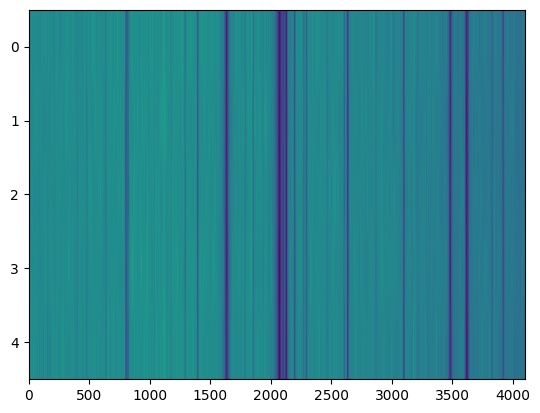

In [3]:
from astropy.io import fits 
import numpy as np 
import matplotlib.pyplot as plt 

with fits.open(paths["products"] / "raw_0.fits") as hdu:
    head = hdu[0].header 
    wave = hdu[0].data
    raw_science = hdu[1].data 

    N_ORDERS = 36
    ORDER_width = 5
    ORDER_SPACING = 50    
    sci = np.zeros((N_ORDERS, raw_science.shape[1]))
    start = head["CCD PIXEL OFFSET"]
    for order in range(N_ORDERS):
        sci[order] = np.sum(raw_science[start:start+ORDER_width, :], axis=0)
        start = start + ORDER_width + ORDER_SPACING

plt.imshow(raw_science[100:100+ORDER_width, :], aspect="auto")

sci /= np.median(sci)
with fits.open("/home/amiguel/class_simulations/real_spectra/r.ESPRE.2021-10-25T06:06:31.460_S2D_A.fits") as real:
    rwave = real[4].data 
    rflux = real[1].data 

rflux /= np.median(rflux)
#rflux *= 10


[1.4230555 1.4289474 1.424238  ... 1.1666666 1.1666092 1.1790074] (4096,)


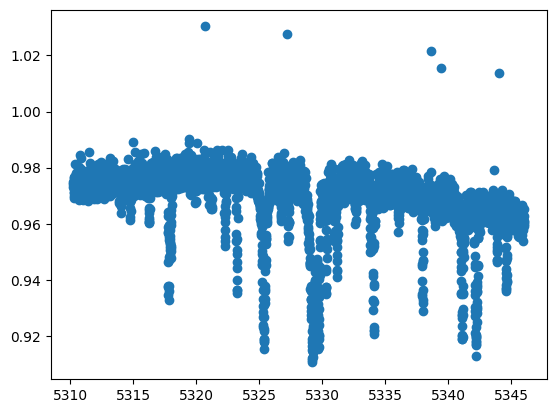

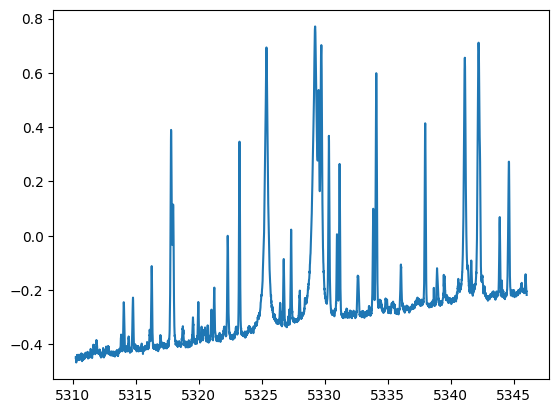

In [4]:
for order in range(N_ORDERS):
    plt.scatter(wave[order], sci[order])
    break 

for order in range(94, 170, 2):
    break
    plt.scatter(rwave[order], rflux[order], s = 10)
    break

inds = [] 
for index, value in enumerate(wave[0]):
    inds.append(np.where(rwave[94] == value)[0][0])
plt.figure()
print(rflux[94][inds], rflux[94][inds].shape)
plt.plot(wave[0], sci[0] - rflux[94][inds])
